## Import Lib

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

## EDA

In [2]:
nodes = pd.read_csv('mc1_nodes.csv')

edges = pd.read_csv('mc1_edges.csv')

In [3]:
# nodes
print(nodes.columns)
print(edges.columns)

Index(['Node Type', 'name', 'single', 'release_date', 'genre', 'notable', 'id',
       'written_date', 'stage_name', 'notoriety_date'],
      dtype='object')
Index(['Edge Type', 'source', 'target', 'key'], dtype='object')


In [4]:
nodes.head()

,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
0,Song,Breaking These Chains,True,2017.0,Oceanus Folk,True,0,NaN,NaN,NaN
1,Person,Carlos Duffy,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN
2,Person,Min Qin,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
3,Person,Xiuying Xie,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN
4,RecordLabel,Nautical Mile Records,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN


In [5]:
edges.head()

,Edge Type,source,target,key
0,InterpolatesFrom,0,1841,0
1,RecordedBy,0,4,0
2,PerformerOf,1,0,0
3,ComposerOf,1,16180,0
4,PerformerOf,2,0,0


In [6]:
## Filter only Oceanus Folk genre
oceanus_folk_nodes = nodes[nodes['genre'] == 'Oceanus Folk']
## Get the IDs of the Oceanus Folk artists
# set is store unique values
oceanus_folk_ids = set(oceanus_folk_nodes['id'])

In [8]:
oceanus_folk_nodes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305 entries, 0 to 17411
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Node Type       305 non-null    object 
 1   name            305 non-null    object 
 2   single          235 non-null    object 
 3   release_date    305 non-null    float64
 4   genre           305 non-null    object 
 5   notable         305 non-null    object 
 6   id              305 non-null    int64  
 7   written_date    91 non-null     float64
 8   stage_name      0 non-null      object 
 9   notoriety_date  38 non-null     float64
dtypes: float64(3), int64(1), object(6)
memory usage: 26.2+ KB


In [10]:
# build influence graph
G = nx.from_pandas_edgelist(
    edges,
    source='source',
    target='target',
    create_using=nx.DiGraph()
)

In [ ]:
# how did influence spread over time
# if target is oceanus folk related, it means that someone is influenced by oceanus folk
edges['target_is_oceanus_folk'] = edges['target'].isin(oceanus_folk_ids)

# number of artists influenced by oceanus folk over time
spread_over_time = edges[edges['target_is_oceanus_folk']].merge(nodes[['id', 'release_date']], left_on='target', right_on='id', how='left').groupby('release_date').size()

In [31]:
edges[edges['target_is_oceanus_folk'] == True]

,Edge Type,source,target,key,target_is_oceanus_folk
2,PerformerOf,1,0,0,True
3,ComposerOf,1,16180,0,True
4,PerformerOf,2,0,0,True
5,ProducerOf,2,16180,0,True
6,PerformerOf,3,0,0,True
...,...,...,...,...,...
37742,RecordedBy,17370,17329,0,True
37743,RecordedBy,17370,17330,0,True
37744,RecordedBy,17370,17331,0,True
37835,LyricistOf,17396,17245,0,True


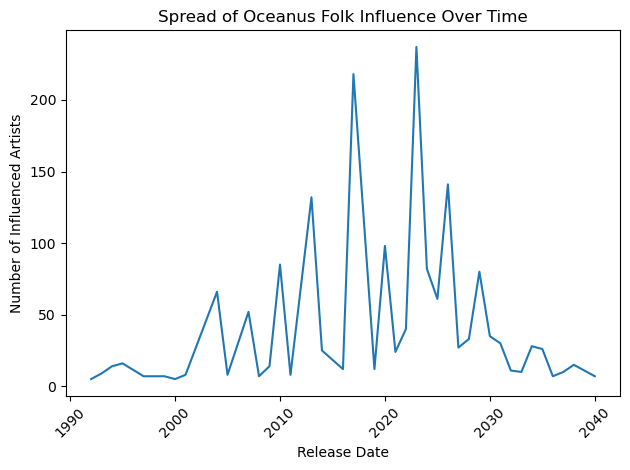

In [25]:
spread_over_time.plot(kind='line')
plt.title('Spread of Oceanus Folk Influence Over Time')
plt.xlabel('Release Date')
plt.ylabel('Number of Influenced Artists')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

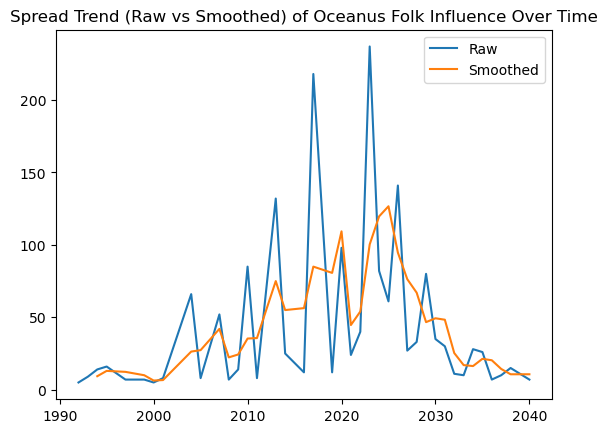

In [33]:
plt.figure()
plt.plot(spread_over_time.index, spread_over_time.values, label='Raw')
# smoothed trend reduce noise by averaging over a window (e.g., rolling mean)
plt.plot(spread_over_time.index, spread_over_time.rolling(3).mean(), label='Smoothed')
plt.legend()
plt.title("Spread Trend (Raw vs Smoothed) of Oceanus Folk Influence Over Time")
plt.show()

In [16]:
# rank spread over time by descending order
spread_over_time.sort_values(ascending=False).head(10)

release_date
2023.0    237
2017.0    218
2026.0    141
2013.0    132
2020.0     98
2010.0     85
2024.0     82
2029.0     80
2004.0     66
2025.0     61
dtype: int64

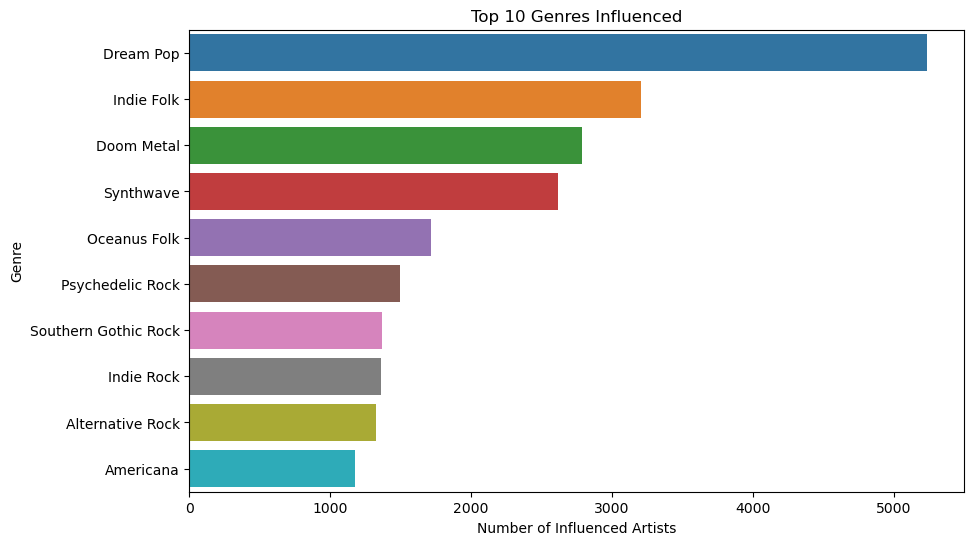

In [32]:
# genres influenced
influenced = edges.merge(nodes[['id', 'genre']], left_on='target', right_on='id', how='left')
influenced_genres = influenced['genre'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=influenced_genres.values, y=influenced_genres.index)
plt.title('Top 10 Genres Influenced')
plt.xlabel('Number of Influenced Artists')
plt.ylabel('Genre')
plt.show()

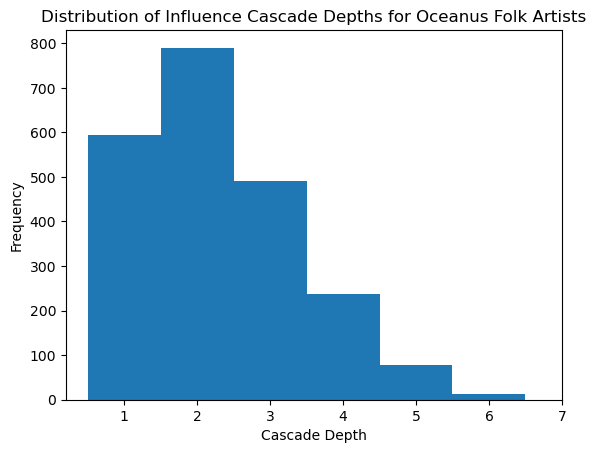

In [21]:
# cascades deapth of spread (how far influence spreads)
lengths = []

for node in oceanus_folk_ids:
    for target in nx.descendants(G, node):
        try:
            length = nx.shortest_path_length(G, source=node, target=target)
            lengths.append(length)
        except nx.NetworkXNoPath:
            continue

plt.hist(lengths, bins=range(1, max(lengths) + 1), align='left')
plt.title('Distribution of Influence Cascade Depths for Oceanus Folk Artists')
plt.xlabel('Cascade Depth')
plt.ylabel('Frequency')
plt.xticks(range(1, max(lengths) + 1))
plt.show()

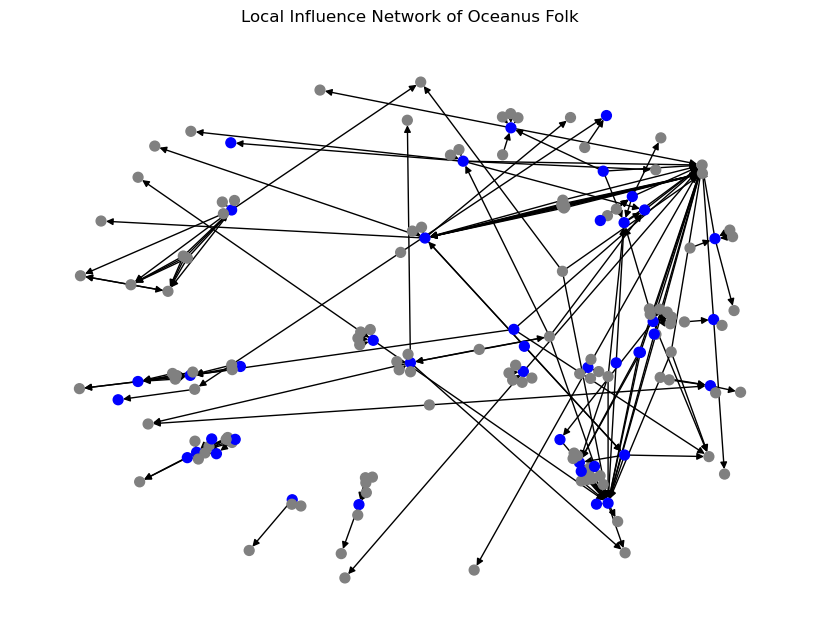

In [ ]:
G = nx.from_pandas_edgelist(edges, 'source', 'target', create_using=nx.DiGraph())

sub_nodes = list(oceanus_folk_ids)[:20]  # limit for clarity
neighbors = set()

for n in sub_nodes:
    neighbors.update(G.successors(n))
    neighbors.update(G.predecessors(n))

subgraph = G.subgraph(sub_nodes + list(neighbors))

plt.figure(figsize=(8,6))

pos = nx.spring_layout(subgraph)

colors = ['blue' if n in oceanus_folk_ids else 'gray' for n in subgraph.nodes()]

nx.draw(subgraph, pos,
        node_color=colors,
        with_labels=False,
        node_size=50)

plt.title("Local Influence Network of Oceanus Folk")
plt.show()

# blue nodes = oceanus folk artists
# gray nodes = influenced artists